# A2: Unsupervised Learning on Time Series Data — Anomaly Detection

**Course:** Machine Learning  
**Department:** Mechanical and Industrial Engineering, NTNU  

**Dataset:** NASA Anomaly Detection Dataset — SMAP & MSL  
**Source:** [Kaggle — patrickfleith/nasa-anomaly-detection-dataset-smap-msl](https://www.kaggle.com/datasets/patrickfleith/nasa-anomaly-detection-dataset-smap-msl)  
**Original paper:** Hundman et al., 2018 — *Detecting Spacecraft Anomalies Using LSTMs and Nonparametric Dynamic Thresholding* (NASA JPL)

---
# 1. Frame the Problem and Look at the Big Picture

## 1.1 Business Objective

**Goal:** Detect anomalies in telemetry time series collected from two NASA spacecraft:
- **SMAP** (Soil Moisture Active Passive) — an Earth-orbiting satellite
- **MSL** (Mars Science Laboratory) — the Curiosity rover on Mars

In operational practice, anomaly detection on spacecraft telemetry enables ground engineers to identify unexpected system behaviour early, investigate potential faults, and prevent mission-critical failures — without requiring continuous human monitoring of hundreds of channels.

**Dataset summary:**

| Spacecraft | Channels | Total timesteps | Labeled anomalies |
|------------|----------|-----------------|-------------------|
| SMAP       | 55       | 429,735         | 69                |
| MSL        | 27       | 66,709          | 36                |

Each channel is stored as a separate `.npy` file. The first column of each file is the raw telemetry reading; remaining columns are pre-engineered command/context features. Labels (anomaly index ranges) are provided in `labeled_anomalies.csv` — **for evaluation only, not used during training**.

## 1.2 How the Solution Will Be Used

**Offline mode (this assignment):**  
Models are trained on the provided anomaly-free training split. The fitted model is then applied to the test split and flagged anomalies are compared against the ground-truth labels in `labeled_anomalies.csv`.

**Online mode (real-time spacecraft monitoring):**  
- Telemetry packets arrive continuously from the spacecraft
- Each incoming reading is appended to a sliding buffer
- The buffer is preprocessed (using the already-fitted scaler) and scored by the model
- If the anomaly score exceeds the pre-calibrated threshold, an alert is raised for the operations team
- The ground station can then cross-check the ISA (Integrated System Anomaly) reports

Online deployment considerations:
- **Latency:** Must score a new sample within the telemetry downlink cadence
- **Statefulness:** The model must be stateless or maintain a compact buffer (rules out standard DBSCAN)
- **Drift:** Spacecraft operating modes change over time — periodic retraining may be needed

## 1.3 Current Solutions / Baselines

- **Rule-based alarm systems:** NASA's existing monitoring uses fixed thresholds on individual telemetry channels — effective only for obvious out-of-range values (point anomalies)
- **Manual review:** Operations engineers periodically inspect telemetry plots and file ISA (Integrated System Anomaly) reports when anomalies are found — time-consuming and not scalable across 55+ channels
- **Statistical process control:** Simple z-score or rolling-mean-deviation alerts — misses contextual anomalies where values are individually normal but anomalous in context

The Hundman et al. (2018) paper used an LSTM + nonparametric dynamic thresholding approach. This assignment compares simpler, more interpretable unsupervised techniques against this context.

## 1.4 Problem Type

- **Unsupervised learning** — models are trained on the clean training split with no anomaly labels
- **Anomaly / novelty detection** on multivariate time series telemetry data
- Two types of anomalies present in the dataset:
  - **Point anomalies** — individual timesteps that are statistically extreme; detectable by distance- or density-based methods
  - **Contextual anomalies** — values that are normal in isolation but anomalous given surrounding context; require temporal modelling to detect

Techniques to implement and compare:
1. **K-Means** — distance to nearest centroid as anomaly score - Sila
2. **DBSCAN** — noise points (label = -1) treated as anomalies - Sila
3. **Gaussian Mixture Model (GMM)** — negative log-likelihood as anomaly score - Tomas
4. **Isolation Forest** — anomaly score from random path lengths - Sila
5. **Local Outlier Factor (LOF)** — local density deviation as anomaly score - Tomas
6. SVM - Sila
7. PCA - Tomas

## 1.5 Performance Measurement

Model performance is evaluated using multiple complementary metrics:

- **F1 score** as the primary comparison metric — balances precision and recall, appropriate for the imbalanced anomaly detection setting
- **Precision and Recall** to separately assess false alarm rate and detection coverage; in spacecraft operations, recall is prioritised (missing an anomaly is more costly than a false alert)
- **AIC / BIC** for selecting the optimal number of components in GMM
- **Silhouette score** for assessing the separation quality of K-Means clusters

Ground-truth labels from `labeled_anomalies.csv` are used exclusively for evaluation — not during training. This combination allows both statistical detection quality and operational practicality to be assessed.

## 1.6 Minimum Performance Requirements

Since ground-truth labels are available in `labeled_anomalies.csv`, we can set concrete targets for the models:

- **F1 score > 0.5** on the test set — a random classifier at ~5% contamination would score ~0.1
- **Recall > 0.6** — missing anomalies is costly in spacecraft operations; recall is prioritised over precision
- **False alarm rate < 10%** — too many false alerts would make the system impractical for operators
- Models should detect anomalies **without being told where they are** (trained only on the clean training split)

---
# 2. Libraries

In [1]:
# Main libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# Unsupervised / Anomaly Detection Models
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

# Metrics
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_recall_curve
)

# General utilities
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plot style
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid')

%load_ext autoreload
%autoreload 2

---
# 3. Get the Data

## 3.1 Load Dataset

**File structure:**
```
archive/
├── labeled_anomalies.csv          # ground-truth labels (chan_id, spacecraft, anomaly_sequences, class, num_values)
└── data/data/
    ├── train/
    │   ├── P-1.npy                # SMAP channel P-1 — training split (anomaly-free)
    │   ├── M-1.npy                # MSL  channel M-1 — training split
    │   └── ...                    # 82 channels total
    └── test/
        ├── P-1.npy                # SMAP channel P-1 — test split (may contain anomalies)
        ├── M-1.npy
        └── ...
```

**Each `.npy` file:** shape `(timesteps, n_features)`  
- Column 0: raw telemetry value for that channel  
- Columns 1+: pre-engineered command/context features (one-hot encoded spacecraft commands)

**Strategy:** We will work on a **single channel** (or a small set) at a time.  
Labels in `labeled_anomalies.csv` give `anomaly_sequences` as `[[start, end], ...]` — index ranges into the **test** array for that channel.

In [2]:
import sys
import os

# Make sure Dataset.py is importable from the project directory
BASE_DIR = os.getcwd()
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

from Dataset import DatasetOperations

# Paths (mirrors Main.py)
train_path       = os.path.join(BASE_DIR, "archive", "data", "data", "train")
test_path        = os.path.join(BASE_DIR, "archive", "data", "data", "test")
result_file_path = os.path.join(BASE_DIR, "archive", "labeled_anomalies.csv")

dt = DatasetOperations(test_path=test_path, train_path=train_path, results_path=result_file_path)
train_dataset, test_dataset, results = dt.load_data()

  --> Scaling unnormalized channel: C-1 (Max value: 2.1934477379095165)
  --> Scaling unnormalized channel: F-5 (Max value: 4.162651279553374)
  --> Scaling unnormalized channel: M-1 (Max value: 2.4922982712327473)
Successfully loaded 82 train channels.
  --> Scaling unnormalized channel: F-5 (Max value: 6.954363220802578)
  --> Scaling unnormalized channel: M-1 (Max value: 2.268853926232979)
  --> Scaling unnormalized channel: M-6 (Max value: 258.1081081081054)
Successfully loaded 82 test channels.
Successfully loaded labels CSV.


## 3.2 Basic Dataset Info

Inspect the loaded arrays and the label file:
- How many timesteps in the train vs test split?
- How many features per channel?
- Which anomaly class is present — point, contextual, or both?
- What percentage of the test set is labeled anomalous?
- Presence of missing values
- check for nonbinary values 

In [3]:
dt.dataset_info()


--- TRAINING DATASET SUMMARY ---
Channel_ID Dimensions Telemetry_Range  Missing_NaN  Non_Binary_Cmds
       A-1  2880 x 25    [1.00, 1.00]            0                0
       A-2  2648 x 25   [-1.00, 1.00]            0                0
       A-3  2736 x 25   [-1.00, 1.00]            0                0
       A-4  2690 x 25   [-1.00, 1.00]            0                0
       A-5   705 x 25  [-1.00, -1.00]            0                0
       A-6   682 x 25   [-1.00, 1.00]            0                0
       A-7  2879 x 25   [-1.00, 1.00]            0                0
       A-8   762 x 25   [-1.00, 1.00]            0                0
       A-9   762 x 25   [-1.00, 1.00]            0                0
       B-1  2435 x 25  [-1.00, -1.00]            0                0
       C-1  2158 x 55   [-1.00, 1.00]            0                0
       C-2   764 x 55  [-1.00, -1.00]            0                0
       D-1  2849 x 25  [-1.00, -0.58]            0                0
      D-11  26

---
# 4. Explore the Data (EDA)

## 4.1 Time Series Visualization

Plot the raw telemetry signal (column 0) for the selected channel(s) over time.  
Overlay the known anomaly windows from `labeled_anomalies.csv` as shaded regions on the **test** portion — this gives a visual intuition of what we are trying to detect.


--- Interactive Plotter Started ---
Controls: [n] Next channel | [b] Previous channel | [ESC] Close
Displaying: A-1


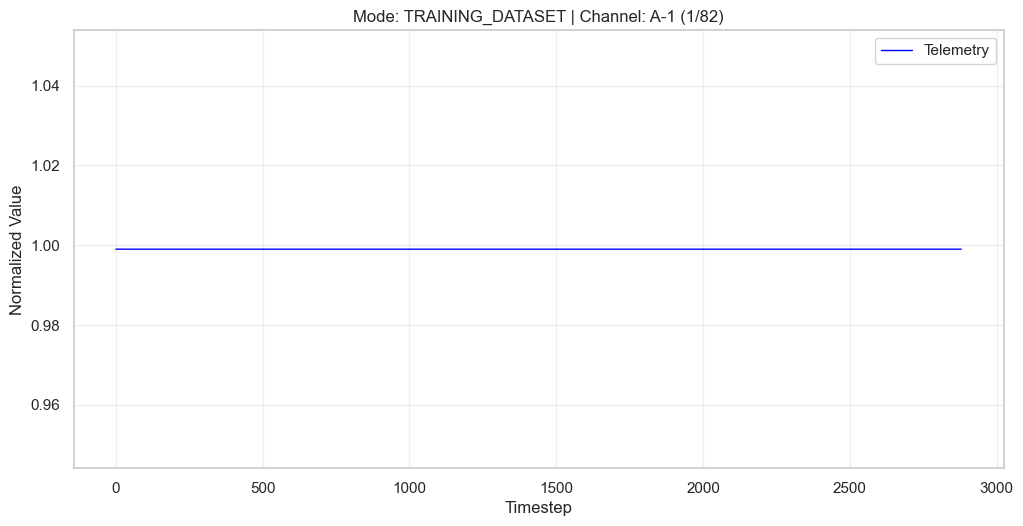

In [4]:
dt.plot_data(choosen_dataset="training_dataset", start_channel_id="A-1")

## 4.2 Correlation Matrix 
corelation check function creates correlation matrix and creates a csv report about correlation between files

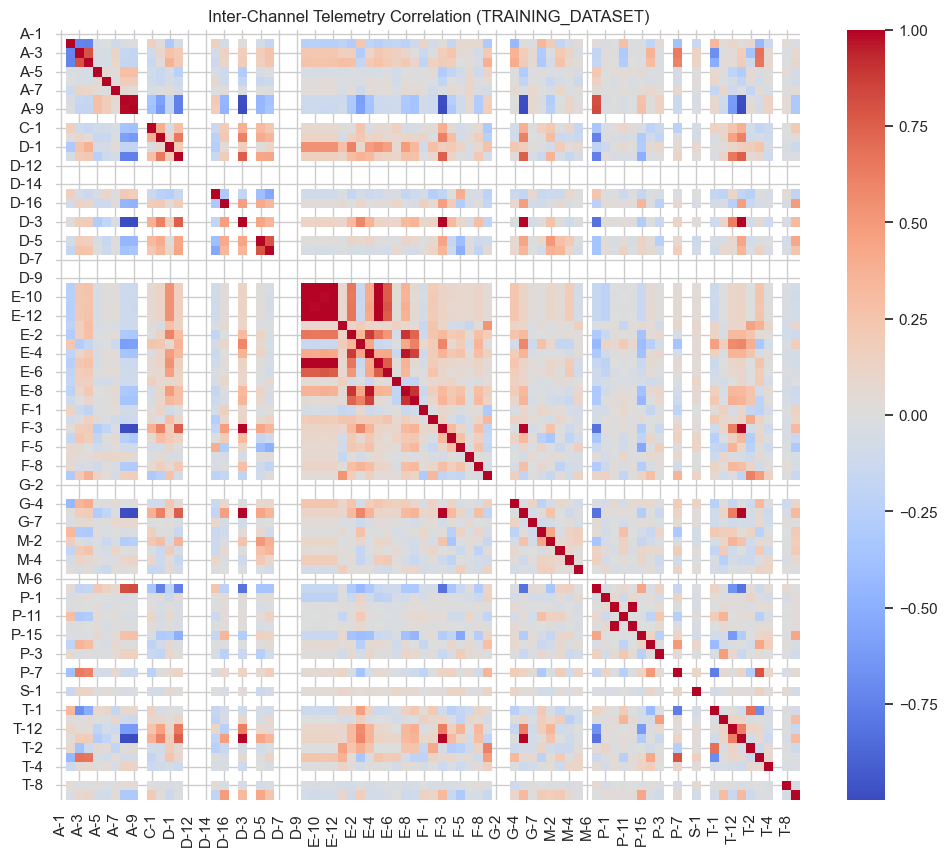

In [5]:
correlation_outfile_path = BASE_DIR
correlation_dictionary = dt.correlation_check(mode="training_dataset",correlation_csv_report = False,correlation_outfile_path=correlation_outfile_path,corr_calc_method="spearman")

## 4.5 Anomaly Label Analysis

Inspect the ground-truth labels from `labeled_anomalies.csv`:
- How many channels have **point** vs **contextual** anomalies?
- What is the average anomaly window length?
- What fraction of each channel's test set is anomalous?

This informs the expected contamination rate and helps set the threshold for each model.

In [6]:
# from statsmodels.tsa.stattools import adfuller
# for col in df.columns:
#     result = adfuller(df[col].dropna())
#     print(f'{col}: ADF={result[0]:.4f}, p-value={result[1]:.4f}')

---
# 5. Prepare the Data

## 5.1 Train / Test Split 

The NASA dataset **already provides a pre-defined chronological train/test split** — no splitting needed:

- `archive/data/data/train/{chan_id}.npy` → training data (anomaly-free, used for fitting models)
- `archive/data/data/test/{chan_id}.npy` → test data (may contain anomalies, evaluated against labels)

Ground-truth labels for the **test set only** are in `labeled_anomalies.csv`.  
The training set is considered clean — this is the standard assumption for unsupervised anomaly detection (train on normal, detect deviations at test time).
First round of method usage will be perform on smaller dataset made up of 10 randomly selected files
Also to lower amount of data function sort_by_corr creates a groups of files with high correlation

In [ ]:
train_data_clustered_by_corr = dt.sort_by_corr(sorting_threshold=0.60, remove_files=False,remove_threshold=None)
train_subset,test_subset = dt.select_subset(random_selection=True, manual_file_names=None, subset_size=10, seed=42)



CLUSTERING & CLEANING REPORT (Sort: 0.6 | Remove: None)
 Group 01: E-6, E-8, E-4, E-5, E-9, E-12, E-3, E-1, E-10, D-1, E-2, E-11
 Group 02: D-11, T-12, F-3, G-6, A-8, A-9, T-13, C-2, P-15, D-3, M-7
 Group 03: A-2, T-2, G-1, A-3, A-4, T-3, P-7, T-1
 Group 04: D-5, D-6
 Group 05: P-14, P-10

Randomly selected 10 files (seed=42).
Selected files: ['T-9', 'D-12', 'A-4', 'E-5', 'E-13', 'E-10', 'D-15', 'D-11', 'R-1', 'C-2']


## 5.2 Feature Engineering

The `.npy` files already include pre-engineered command features alongside the raw telemetry. Options:

- **Use as-is:** All columns (raw telemetry + command features)
- **Telemetry only:** Column 0 only — simplest, but loses command context
- **Rolling statistics:** Add sliding-window mean and std of the telemetry value to capture local temporal behaviour — especially useful for detecting **contextual anomalies**
- **Lag features:** Append previous timestep values to give models short-term memory

In [8]:
# Rolling statistics (sliding window mean/std)
WINDOW = 10  # adjust to dataset sampling rate

# Example:
# df_features = df.copy()
# for col in df.columns:
#     df_features[f'{col}_roll_mean'] = df[col].rolling(WINDOW).mean()
#     df_features[f'{col}_roll_std']  = df[col].rolling(WINDOW).std()
# df_features.dropna(inplace=True)

## 5.3 Preprocessing Pipeline

In [9]:
# Build sklearn pipeline for consistent preprocessing
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# X_train = preprocessor.fit_transform(df_train)
# X_test  = preprocessor.transform(df_test)

## 5.4 Dimensionality Reduction — PCA (for visualization)

In [10]:
# pca = PCA(n_components=2, random_state=RANDOM_SEED)
# X_train_2d = pca.fit_transform(X_train)
# print(f'Explained variance ratio: {pca.explained_variance_ratio_}')

# plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], s=1, alpha=0.5)
# plt.title('PCA — Training Data')
# plt.xlabel('PC1'); plt.ylabel('PC2')
# plt.show()

---
# 6. Explore Many Different Models and Shortlist the Best Ones

## 6.1 Helper Functions

In [11]:
def plot_anomaly_scores(scores, title='Anomaly Score', threshold=None):
    """Plot anomaly scores over time and mark flagged points."""
    plt.figure(figsize=(14, 4))
    plt.plot(scores, linewidth=0.7, label='Anomaly score')
    if threshold is not None:
        plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.3f}')
        anomalies = np.where(scores > threshold)[0]
        plt.scatter(anomalies, scores[anomalies], color='red', s=10, zorder=5, label='Anomalies')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_model(y_true, y_pred, model_name='Model'):
    """Print classification metrics when ground-truth labels are available."""
    print(f'\n=== {model_name} ===')
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly']))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Anomaly'],
                yticklabels=['Normal', 'Anomaly'])
    plt.title(f'{model_name} — Confusion Matrix')
    plt.show()

## 6.2 Model 1: K-Means Clustering

In [12]:
# --- Elbow method to choose K ---
# inertia = []
# K_range = range(2, 15)
# for k in K_range:
#     km = KMeans(n_clusters=k, random_state=RANDOM_SEED)
#     km.fit(X_train)
#     inertia.append(km.inertia_)

# plt.plot(K_range, inertia, marker='o')
# plt.xlabel('Number of clusters K')
# plt.ylabel('Inertia')
# plt.title('Elbow Method — K-Means')
# plt.show()

In [13]:
K_BEST = 3  # replace after elbow inspection

# kmeans = KMeans(n_clusters=K_BEST, random_state=RANDOM_SEED)
# kmeans.fit(X_train)

# Anomaly score = distance to nearest cluster centroid
# distances_train = kmeans.transform(X_train).min(axis=1)
# distances_test  = kmeans.transform(X_test).min(axis=1)

# Threshold = 95th percentile of training distances
# threshold_kmeans = np.percentile(distances_train, 95)
# anomalies_kmeans = (distances_test > threshold_kmeans).astype(int)

# plot_anomaly_scores(distances_test, title='K-Means Anomaly Scores', threshold=threshold_kmeans)
# print(f'K-Means flagged {anomalies_kmeans.sum()} anomalies ({100*anomalies_kmeans.mean():.1f}%)')

## 6.3 Model 2: DBSCAN

In [14]:
# --- K-distance plot to choose eps ---
# from sklearn.neighbors import NearestNeighbors
# nn = NearestNeighbors(n_neighbors=5)
# nn.fit(X_train)
# distances, _ = nn.kneighbors(X_train)
# k_distances = np.sort(distances[:, -1])

# plt.plot(k_distances)
# plt.xlabel('Points sorted by distance')
# plt.ylabel('5-NN distance')
# plt.title('K-Distance Graph (choose eps at the knee)')
# plt.show()

In [15]:
EPS         = 0.5   # replace after k-distance inspection
MIN_SAMPLES = 10

# dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
# labels_dbscan = dbscan.fit_predict(X_train)

# Points labeled -1 are outliers / anomalies
# anomalies_dbscan = (labels_dbscan == -1).astype(int)
# print(f'DBSCAN flagged {anomalies_dbscan.sum()} anomalies ({100*anomalies_dbscan.mean():.1f}%)')

# Visualize in PCA space
# plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=labels_dbscan, cmap='tab10', s=2)
# plt.title('DBSCAN Clusters (PCA space, -1 = anomaly)')
# plt.colorbar()
# plt.show()

## 6.4 Model 3: Gaussian Mixture Model (GMM)

In [16]:
# --- Select number of components using BIC / AIC ---
# bic_scores, aic_scores = [], []
# N_range = range(1, 12)
# for n in N_range:
#     gmm = GaussianMixture(n_components=n, random_state=RANDOM_SEED)
#     gmm.fit(X_train)
#     bic_scores.append(gmm.bic(X_train))
#     aic_scores.append(gmm.aic(X_train))

# plt.plot(N_range, bic_scores, marker='o', label='BIC')
# plt.plot(N_range, aic_scores, marker='s', label='AIC')
# plt.xlabel('Number of components')
# plt.ylabel('Score')
# plt.title('GMM Model Selection — BIC/AIC')
# plt.legend()
# plt.show()

In [17]:
N_COMPONENTS_GMM = 3  # replace after BIC/AIC inspection

# gmm = GaussianMixture(n_components=N_COMPONENTS_GMM, covariance_type='full', random_state=RANDOM_SEED)
# gmm.fit(X_train)

# Anomaly score = negative log-likelihood
# log_prob_train = gmm.score_samples(X_train)
# log_prob_test  = gmm.score_samples(X_test)

# threshold_gmm = np.percentile(log_prob_train, 5)  # low density = anomaly
# anomalies_gmm = (log_prob_test < threshold_gmm).astype(int)

# plot_anomaly_scores(-log_prob_test, title='GMM Anomaly Scores (−log p)', threshold=-threshold_gmm)
# print(f'GMM flagged {anomalies_gmm.sum()} anomalies ({100*anomalies_gmm.mean():.1f}%)')

## 6.5 Model 4: Isolation Forest

In [18]:
CONTAMINATION = 0.05  # expected fraction of anomalies

# iso_forest = IsolationForest(contamination=CONTAMINATION, random_state=RANDOM_SEED)
# iso_forest.fit(X_train)

# scores_if = iso_forest.decision_function(X_test)  # lower = more anomalous
# preds_if  = iso_forest.predict(X_test)             # -1 = anomaly, 1 = normal
# anomalies_if = (preds_if == -1).astype(int)

# plot_anomaly_scores(-scores_if, title='Isolation Forest Anomaly Scores')
# print(f'Isolation Forest flagged {anomalies_if.sum()} anomalies ({100*anomalies_if.mean():.1f}%)')

## 6.6 Model 5: Local Outlier Factor (LOF)

In [19]:
# lof = LocalOutlierFactor(n_neighbors=20, contamination=CONTAMINATION, novelty=True)
# lof.fit(X_train)

# scores_lof = lof.decision_function(X_test)
# preds_lof  = lof.predict(X_test)
# anomalies_lof = (preds_lof == -1).astype(int)

# plot_anomaly_scores(-scores_lof, title='LOF Anomaly Scores')
# print(f'LOF flagged {anomalies_lof.sum()} anomalies ({100*anomalies_lof.mean():.1f}%)')

---
# 7. Fine-Tune the Models and Combine into a Great Solution

## 7.1 Model Comparison Summary

In [20]:
# Summarise flagged anomaly rates and (if labels available) F1 scores
results = {
    'K-Means':          {'anomaly_rate_%': None, 'F1': None},
    'DBSCAN':           {'anomaly_rate_%': None, 'F1': None},
    'GMM':              {'anomaly_rate_%': None, 'F1': None},
    'Isolation Forest': {'anomaly_rate_%': None, 'F1': None},
    'LOF':              {'anomaly_rate_%': None, 'F1': None},
}

results_df = pd.DataFrame(results).T
print(results_df)

                 anomaly_rate_%    F1
K-Means                    None  None
DBSCAN                     None  None
GMM                        None  None
Isolation Forest           None  None
LOF                        None  None


## 7.2 Threshold Sensitivity Analysis

In [21]:
# How does anomaly rate change with threshold percentile?
# thresholds = np.percentile(distances_train, np.arange(90, 100, 0.5))
# anomaly_rates = [(distances_test > t).mean() for t in thresholds]

# plt.plot(np.arange(90, 100, 0.5), np.array(anomaly_rates)*100)
# plt.xlabel('Training percentile threshold')
# plt.ylabel('Anomaly rate on test (%)')
# plt.title('K-Means Threshold Sensitivity')
# plt.show()

## 7.3 Ensemble / Best Model Selection

In [22]:
# Majority voting ensemble
# votes = np.stack([anomalies_kmeans, anomalies_gmm, anomalies_if, anomalies_lof], axis=1)
# anomalies_ensemble = (votes.sum(axis=1) >= 2).astype(int)
# print(f'Ensemble flagged {anomalies_ensemble.sum()} anomalies ({100*anomalies_ensemble.mean():.1f}%)')

## 7.4 Visualise Final Anomalies on Raw Signal

In [23]:
# Overlay anomaly flags on the original time series
# fig, ax = plt.subplots(figsize=(16, 4))
# ax.plot(df_test.index, df_test.iloc[:, 0], linewidth=0.7, label='Signal')
# anomaly_idx = df_test.index[anomalies_ensemble == 1]
# ax.scatter(anomaly_idx, df_test.iloc[:, 0].loc[anomaly_idx],
#            color='red', s=10, zorder=5, label='Flagged anomaly')
# ax.set_title('Detected Anomalies on Test Set')
# ax.legend()
# plt.tight_layout()
# plt.show()

---
# 8. Online Deployment Discussion

### How to Use the Solution in Online (Real-Time) Mode

In a real NASA ground operations context, telemetry data streams in continuously from the spacecraft. Here is how the trained model would be integrated:

| Aspect | Approach |
|--------|----------|
| **Data ingestion** | Each incoming telemetry packet is appended to a rolling buffer of fixed length |
| **Preprocessing** | The buffer is transformed using the already-fitted `StandardScaler` (fitted on training data) |
| **Inference** | The preprocessed buffer is scored by the model (e.g., GMM log-likelihood or Isolation Forest score) |
| **Decision** | If the score exceeds the pre-calibrated threshold, the timestep is flagged as anomalous |
| **Alert** | An alert is forwarded to the spacecraft operations team for review against ISA reports |
| **Model refresh** | Periodically retrain on a recent window of confirmed-normal telemetry to account for mission phase changes |

**Model suitability for online use:**

| Model | Online-compatible? | Notes |
|-------|--------------------|-------|
| K-Means | Yes | Store centroids; compute distance per new sample |
| DBSCAN | No (without adaptation) | Requires access to full dataset at inference time |
| GMM | Yes | Evaluate log-likelihood per new sample — very fast |
| Isolation Forest | Yes | Score each sample independently after training |
| LOF | Yes (with `novelty=True`) | Requires storing training data for neighbour queries |

**Recommended online pipeline:**  
`Telemetry stream → Rolling buffer → StandardScaler → GMM or Isolation Forest → Threshold → Alert`

---
# 9. ML Project Checklist Report

### Frame the Problem
- [ ] Business objective defined (spacecraft anomaly detection — SMAP & MSL)
- [ ] Problem type identified (unsupervised anomaly detection on multivariate time series)
- [ ] Performance metrics selected (F1, Precision, Recall against labeled_anomalies.csv)

### Get the Data
- [ ] Dataset loaded from `archive/data/data/train/` and `archive/data/data/test/`
- [ ] Ground-truth labels loaded from `archive/labeled_anomalies.csv`
- [ ] Channel selection documented (which channels are analysed and why)

### Explore the Data
- [ ] Raw telemetry signals plotted with ground-truth anomaly windows overlaid
- [ ] Missing values checked
- [ ] Distributions inspected
- [ ] Correlations analysed
- [ ] Anomaly label breakdown analysed (point vs contextual, anomaly rate per channel)

### Prepare the Data
- [ ] Pre-defined train/test split confirmed (no manual splitting needed)
- [ ] Preprocessing pipeline fitted on training data only
- [ ] Feature engineering documented (rolling stats, lag features, or raw)
- [ ] Ground-truth label arrays constructed for the test set
- [ ] No data leakage from test to train confirmed

### Model Exploration
- [ ] K-Means implemented (elbow method for K, centroid distance as score)
- [ ] DBSCAN implemented (k-distance plot for eps)
- [ ] GMM implemented (BIC/AIC for n_components, log-likelihood as score)
- [ ] Isolation Forest implemented
- [ ] LOF implemented
- [ ] All models evaluated on same channel(s) using F1, Precision, Recall

### Fine-Tune
- [ ] Hyperparameters tuned for best models
- [ ] Threshold sensitivity analysed
- [ ] Ensemble / best model selected and justified
- [ ] Final anomalies visualised overlaid on raw telemetry

### Online Deployment
- [ ] Online pipeline described (buffer → scaler → model → threshold → alert)
- [ ] Model-by-model online suitability assessed
- [ ] Concept drift / model refresh strategy outlined

---
### Summary

**Best performing model:** [TBD]  
**Why it outperforms others:** [TBD — discuss point vs contextual anomalies, feature space geometry, etc.]  
**Recommended online model:** [TBD]  
**Key anomalies detected:** [TBD — describe what was found and on which channels]